In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veri setlerini yükle
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
category_translation = pd.read_csv('../data/raw/product_category_name_translation.csv')

print("Veri setleri başarıyla yüklendi!")
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Products: {products.shape}")
print(f"Customers: {customers.shape}")
print(f"Sellers: {sellers.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Payments: {payments.shape}")

Veri setleri başarıyla yüklendi!
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Sellers: (3095, 4)
Reviews: (99224, 7)
Payments: (103886, 5)


In [2]:
# Her tablonun ilk 5 satırına ve sütun isimlerine bakalım
print("="*50)
print("ORDERS")
print("="*50)
print(orders.head())
print("\nSütunlar:", orders.columns.tolist())

print("\n" + "="*50)
print("ORDER ITEMS")
print("="*50)
print(order_items.head())
print("\nSütunlar:", order_items.columns.tolist())

print("\n" + "="*50)
print("PRODUCTS")
print("="*50)
print(products.head())
print("\nSütunlar:", products.columns.tolist())

ORDERS
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           

In [3]:
print("EKSİK VERİ ANALİZİ")
print("="*50)

for name, df in [("Orders", orders), ("Order Items", order_items), 
                  ("Products", products), ("Customers", customers),
                  ("Sellers", sellers), ("Reviews", reviews), ("Payments", payments)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        for col, count in missing.items():
            print(f"  {col}: {count} eksik ({count/len(df)*100:.1f}%)")
    else:
        print(f"\n{name}: Eksik veri yok ✓")

EKSİK VERİ ANALİZİ

Orders:
  order_approved_at: 160 eksik (0.2%)
  order_delivered_carrier_date: 1783 eksik (1.8%)
  order_delivered_customer_date: 2965 eksik (3.0%)

Order Items: Eksik veri yok ✓

Products:
  product_category_name: 610 eksik (1.9%)
  product_name_lenght: 610 eksik (1.9%)
  product_description_lenght: 610 eksik (1.9%)
  product_photos_qty: 610 eksik (1.9%)
  product_weight_g: 2 eksik (0.0%)
  product_length_cm: 2 eksik (0.0%)
  product_height_cm: 2 eksik (0.0%)
  product_width_cm: 2 eksik (0.0%)

Customers: Eksik veri yok ✓

Sellers: Eksik veri yok ✓

Reviews:
  review_comment_title: 87656 eksik (88.3%)
  review_comment_message: 58247 eksik (58.7%)

Payments: Eksik veri yok ✓


In [4]:
print("VERİ TİPLERİ")
print("="*50)
print("\nOrders:")
print(orders.dtypes)
print("\nOrder Items:")
print(order_items.dtypes)

VERİ TİPLERİ

Orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Order Items:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


In [5]:
# Tarih sütunlarını datetime'a çevir
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at', 
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Kontrol edelim
print("Dönüşüm sonrası Orders veri tipleri:")
print(orders.dtypes)
print("\nTarih aralığı:")
print(f"İlk sipariş: {orders['order_purchase_timestamp'].min()}")
print(f"Son sipariş: {orders['order_purchase_timestamp'].max()}")
print(f"Toplam süre: {(orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()).days} gün")

Dönüşüm sonrası Orders veri tipleri:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Tarih aralığı:
İlk sipariş: 2016-09-04 21:15:19
Son sipariş: 2018-10-17 17:30:18
Toplam süre: 772 gün


In [6]:
print("SİPARİŞ DURUMLARI")
print("="*50)
print(orders['order_status'].value_counts())
print(f"\nToplam sipariş: {len(orders)}")
print(f"Sadece 'delivered': {len(orders[orders['order_status']=='delivered'])}")
print(f"Kullanılabilir oran: {len(orders[orders['order_status']=='delivered'])/len(orders)*100:.1f}%")

SİPARİŞ DURUMLARI
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Toplam sipariş: 99441
Sadece 'delivered': 96478
Kullanılabilir oran: 97.0%


In [7]:
# Sadece delivered siparişleri al
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Tabloları birleştir
df = orders_delivered.merge(order_items, on='order_id', how='inner')
df = df.merge(products, on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
df = df.merge(sellers[['seller_id', 'seller_state', 'seller_city']], on='seller_id', how='left')

# Kontrol
print(f"Ana tablo boyutu: {df.shape}")
print(f"\nSütunlar:")
print(df.columns.tolist())

Ana tablo boyutu: (110197, 27)

Sütunlar:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_state', 'customer_city', 'seller_state', 'seller_city']


In [8]:
print("FİYAT ANALİZİ")
print("="*50)
print(df['price'].describe())

print("\nAykırı değer kontrolü:")
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Alt sınır: {lower:.2f}")
print(f"Üst sınır: {upper:.2f}")
print(f"Aykırı değer sayısı: {len(df[(df['price'] < lower) | (df['price'] > upper)])}")
print(f"Aykırı değer oranı: {len(df[(df['price'] < lower) | (df['price'] > upper)])/len(df)*100:.1f}%")

FİYAT ANALİZİ
count    110197.000000
mean        119.980563
std         182.299446
min           0.850000
25%          39.900000
50%          74.900000
75%         134.170000
max        6735.000000
Name: price, dtype: float64

Aykırı değer kontrolü:
Q1: 39.90
Q3: 134.17
IQR: 94.27
Alt sınır: -101.50
Üst sınır: 275.57
Aykırı değer sayısı: 8162
Aykırı değer oranı: 7.4%


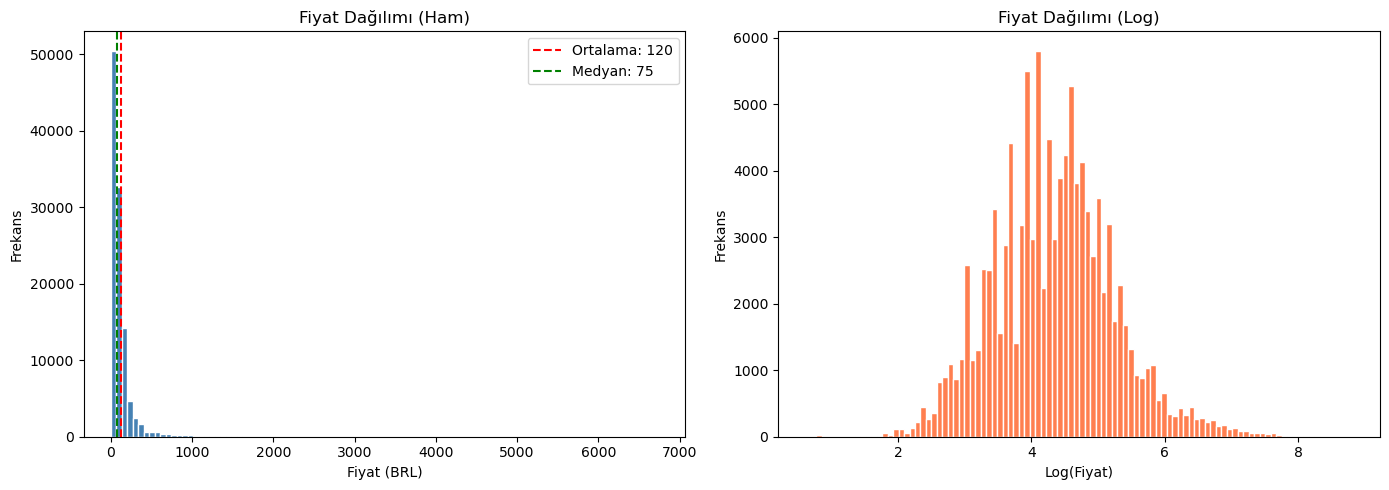

Grafik kaydedildi!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Ham fiyat dağılımı
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Fiyat Dağılımı (Ham)')
axes[0].set_xlabel('Fiyat (BRL)')
axes[0].set_ylabel('Frekans')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Ortalama: {df['price'].mean():.0f}")
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f"Medyan: {df['price'].median():.0f}")
axes[0].legend()

# Sağ: Log dönüşümlü fiyat dağılımı
axes[1].hist(np.log1p(df['price']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Fiyat Dağılımı (Log)')
axes[1].set_xlabel('Log(Fiyat)')
axes[1].set_ylabel('Frekans')

plt.tight_layout()
plt.savefig('../outputs/figures/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi!")

In [10]:
# Kategori bazında satış analizi
category_stats = df.groupby('product_category_name_english').agg(
    satis_adedi=('order_id', 'count'),
    ort_fiyat=('price', 'mean'),
    medyan_fiyat=('price', 'median'),
    toplam_gelir=('price', 'sum')
).sort_values('satis_adedi', ascending=False).round(2)

print("EN ÇOK SATAN KATEGORİLER (Top 15)")
print("="*60)
print(category_stats.head(15))

EN ÇOK SATAN KATEGORİLER (Top 15)
                               satis_adedi  ort_fiyat  medyan_fiyat  \
product_category_name_english                                         
bed_bath_table                       10953      93.44         79.05   
health_beauty                         9465     130.28         79.90   
sports_leisure                        8431     113.25         77.90   
furniture_decor                       8160      87.25         65.49   
computers_accessories                 7644     116.26         81.99   
housewares                            6795      90.60         59.70   
watches_gifts                         5859     199.04        128.99   
telephony                             4430      69.95         29.99   
garden_tools                          4268     110.24         59.90   
auto                                  4140     139.85         84.90   
toys                                  4030     116.94         79.90   
cool_stuff                            3718 

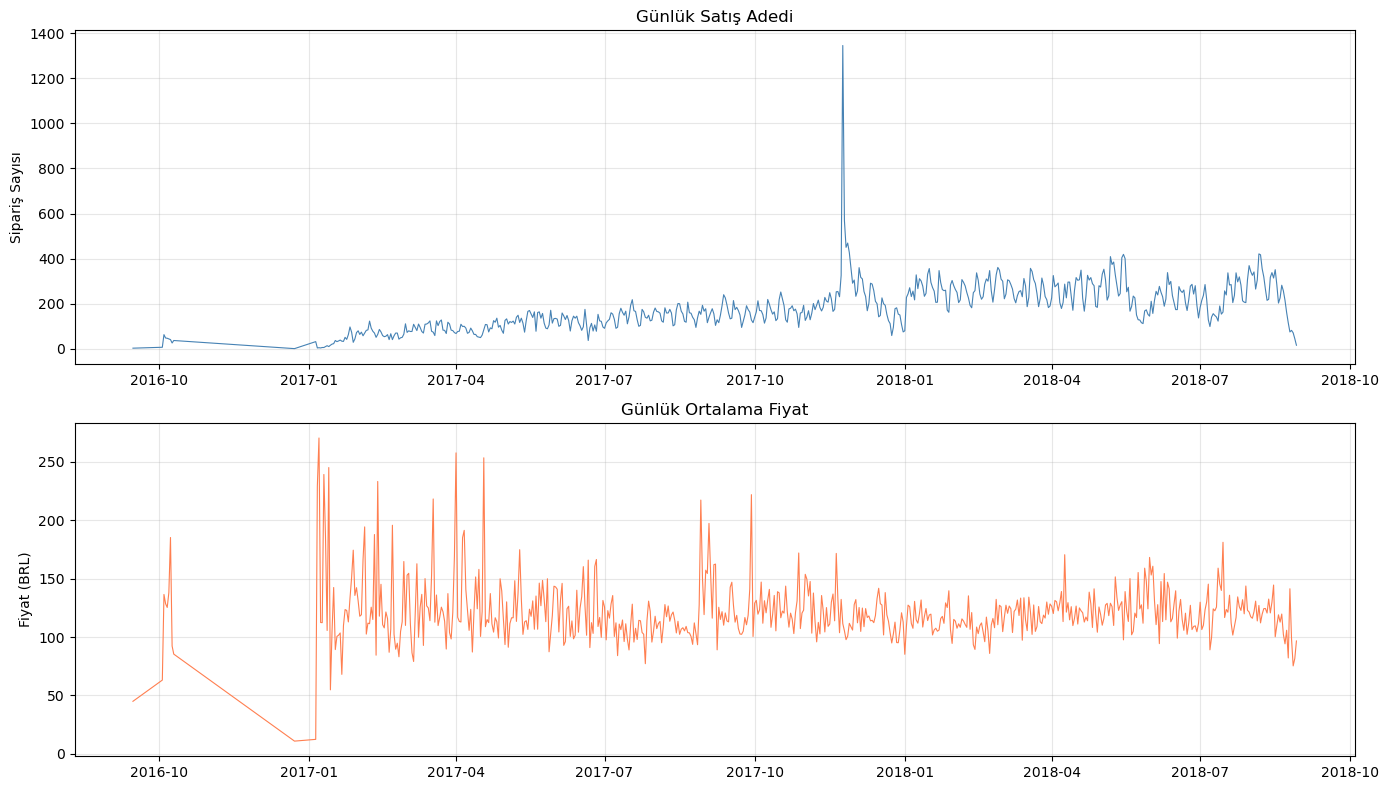

Grafik kaydedildi!


In [11]:
# Günlük satış trendini çıkar
df['order_date'] = df['order_purchase_timestamp'].dt.date
daily_sales = df.groupby('order_date').agg(
    satis_adedi=('order_id', 'count'),
    toplam_gelir=('price', 'sum'),
    ort_fiyat=('price', 'mean')
).reset_index()

daily_sales['order_date'] = pd.to_datetime(daily_sales['order_date'])
daily_sales = daily_sales.sort_values('order_date')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Günlük satış adedi
axes[0].plot(daily_sales['order_date'], daily_sales['satis_adedi'], 
             color='steelblue', linewidth=0.8)
axes[0].set_title('Günlük Satış Adedi')
axes[0].set_ylabel('Sipariş Sayısı')
axes[0].grid(True, alpha=0.3)

# Günlük ortalama fiyat
axes[1].plot(daily_sales['order_date'], daily_sales['ort_fiyat'], 
             color='coral', linewidth=0.8)
axes[1].set_title('Günlük Ortalama Fiyat')
axes[1].set_ylabel('Fiyat (BRL)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi!")

Kırpma sonrası satır sayısı: 109880
Tarih aralığı: 2017-01-05 11:56:06 - 2018-08-29 15:00:37


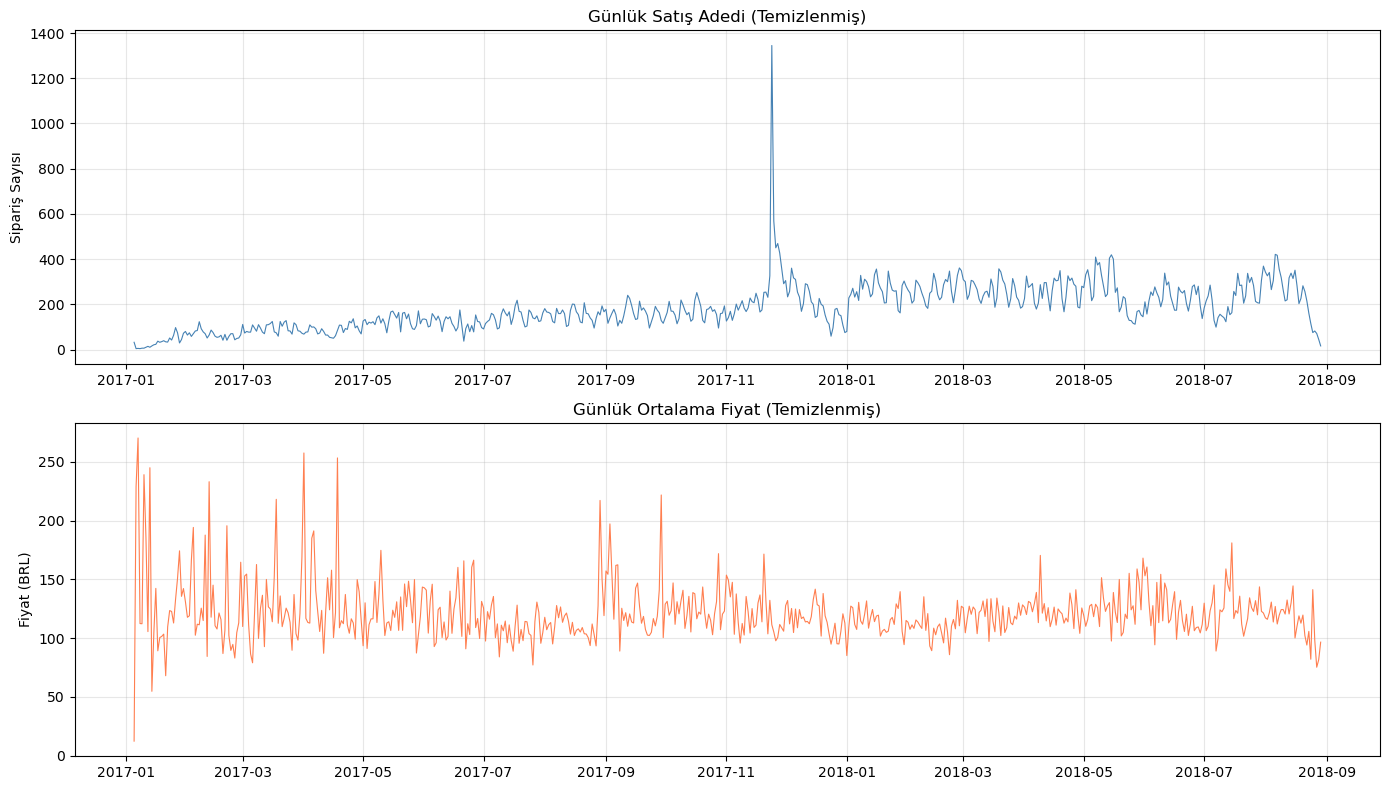

Kalan veri: 109880 satır


In [12]:
# 2017 başı öncesi ve 2018-09 sonrasını çıkar
df = df[(df['order_purchase_timestamp'] >= '2017-01-01') & 
        (df['order_purchase_timestamp'] <= '2018-08-31')]

print(f"Kırpma sonrası satır sayısı: {len(df)}")
print(f"Tarih aralığı: {df['order_purchase_timestamp'].min()} - {df['order_purchase_timestamp'].max()}")

# Günlük satışı tekrar çiz
df['order_date'] = df['order_purchase_timestamp'].dt.date
daily_sales = df.groupby('order_date').agg(
    satis_adedi=('order_id', 'count'),
    ort_fiyat=('price', 'mean')
).reset_index()
daily_sales['order_date'] = pd.to_datetime(daily_sales['order_date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_sales['order_date'], daily_sales['satis_adedi'], 
             color='steelblue', linewidth=0.8)
axes[0].set_title('Günlük Satış Adedi (Temizlenmiş)')
axes[0].set_ylabel('Sipariş Sayısı')
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_sales['order_date'], daily_sales['ort_fiyat'], 
             color='coral', linewidth=0.8)
axes[1].set_title('Günlük Ortalama Fiyat (Temizlenmiş)')
axes[1].set_ylabel('Fiyat (BRL)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/time_series_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Kalan veri: {len(df)} satır")

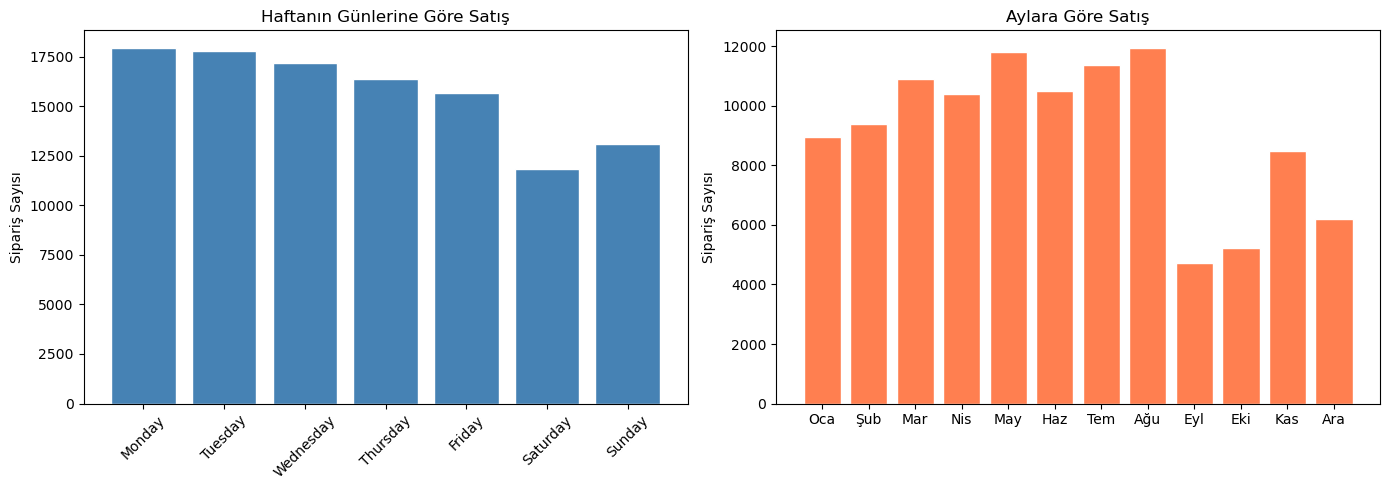

In [13]:
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['month'] = df['order_purchase_timestamp'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Haftanın günlerine göre satış
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = df.groupby('day_of_week')['order_id'].count().reindex(day_order)

axes[0].bar(day_order, day_sales.values, color='steelblue', edgecolor='white')
axes[0].set_title('Haftanın Günlerine Göre Satış')
axes[0].set_ylabel('Sipariş Sayısı')
axes[0].tick_params(axis='x', rotation=45)

# Aylara göre satış
month_sales = df.groupby('month')['order_id'].count()
month_names = ['Oca','Şub','Mar','Nis','May','Haz','Tem','Ağu','Eyl','Eki','Kas','Ara']
axes[1].bar(month_names, month_sales.values, color='coral', edgecolor='white')
axes[1].set_title('Aylara Göre Satış')
axes[1].set_ylabel('Sipariş Sayısı')

plt.tight_layout()
plt.savefig('../outputs/figures/seasonality.png', dpi=150, bbox_inches='tight')
plt.show()